## Phase 1

In [1]:
import json
from pathlib import Path

import pandas as pd
import polars as pl
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

=== files ===
battery_metrics.parquet             96.42 MB
devices.csv                          0.05 MB
eol_times.csv                        0.01 MB
scenarios.json                       2.18 MB

=== devices.csv ===
Unnamed: 0      int64
device_id      object
building_id    object
room_id        object
start_time     object
end_time       object
dtype: object


,Unnamed: 0,device_id,building_id,room_id,start_time,end_time
0,54,d_f44ef99c6628,b_b7e9d5634ad3,r_484904c730d7,2023-07-11 11:18:00+00:00,2026-08-01 08:56:35.604152+00:00
1,55,d_57e99ff00802,b_b7e9d5634ad3,r_484904c730d7,2023-07-11 11:18:00+00:00,2026-08-01 08:56:35.604152+00:00
2,56,d_e1772c236402,b_b7e9d5634ad3,r_484904c730d7,2023-07-11 11:18:00+00:00,2026-08-01 08:56:35.604152+00:00
3,57,d_3703f0819960,b_b7e9d5634ad3,r_484904c730d7,2023-07-11 11:18:00+00:00,2026-08-01 08:56:35.604152+00:00
4,62,d_2fb7a37dadcd,b_afdd8b1a066d,r_68e2b99fbf02,2023-01-11 17:16:00+00:00,2026-08-01 08:56:35.604152+00:00



=== eol_times.csv ===
device_id            object
end_time     datetime64[ns]
dtype: object


,device_id,end_time
0,d_f44ef99c6628,NaT
1,d_57e99ff00802,2026-02-02
2,d_e1772c236402,NaT
3,d_3703f0819960,2025-09-25
4,d_2fb7a37dadcd,NaT



EOL recorded: 82 / 461 (17.8%)
Censored (no EOL yet): 379 (82.2%)

devices vs eol_times device sets equal: True
only in devices: set()
only in eol_times: set()

=== scenarios.json ===
n_scenarios: 48
first start_time: 2025-09-01T00:00:00
last start_time: 2026-07-27T00:00:00
{
  "base_location": "b_955300d5f090",
  "base_room": "r_2823849bded1",
  "planning_window_days": 42,
  "early_replacement_penalty_daily": 0.5,
  "late_replacement_penalty_daily": 10.0,
  "unobserved_eol_days": 30.0,
  "overtime_start": 8.0,
  "overtime_penalty_factor": 2.0,
  "time_per_battery_hours": 0.25,
  "time_per_room_change_hours": 0.5,
  "time_per_building_change_hours": 1.0,
  "worker_limit_weekly_hours": 24.0,
  "worker_limit_weekly_penalty": 100.0,
  "worker_limit_daily_hours": 24.0,
  "worker_limit_daily_penalty": 100.0
}

=== battery_metrics.parquet schema ===
required group field_id=-1 schema {
  optional int64 field_id=-1 end_time (Timestamp(isAdjustedToUTC=false, timeUnit=microseconds, is_from_conv

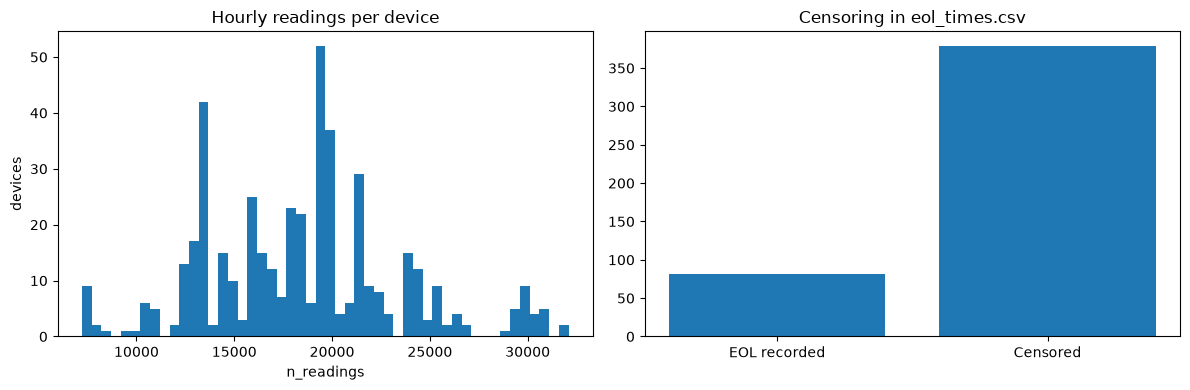

In [4]:
pd.set_option("display.max_columns", 20)

DATA_DIR = Path("../data/raw/train")
assert DATA_DIR.exists(), DATA_DIR.resolve()

# 1. File inventory
print("=== files ===")
for f in sorted(DATA_DIR.glob("*")):
    print(f"{f.name:30s} {f.stat().st_size/1e6:10.2f} MB")

# 2. Small tables — safe to load fully
devices = pd.read_csv(DATA_DIR / "devices.csv")
eol = pd.read_csv(DATA_DIR / "eol_times.csv")
eol["end_time"] = pd.to_datetime(eol["end_time"])

print("\n=== devices.csv ===")
print(devices.dtypes)
display(devices.head())

print("\n=== eol_times.csv ===")
print(eol.dtypes)
display(eol.head())

eol_present = eol["end_time"].notna()
print(f"\nEOL recorded: {eol_present.sum()} / {len(eol)} ({eol_present.mean():.1%})")
print(f"Censored (no EOL yet): {(~eol_present).sum()} ({(~eol_present).mean():.1%})")

# 3. Device-set cross-check (mirrors what load_dataset()'s check_dataset does)
devices_set = set(devices["device_id"])
eol_set = set(eol["device_id"])
print("\ndevices vs eol_times device sets equal:", devices_set == eol_set)
print("only in devices:", devices_set - eol_set)
print("only in eol_times:", eol_set - devices_set)

# 4. Scenarios
with open(DATA_DIR / "scenarios.json") as fh:
    scenarios_raw = json.load(fh)
print("\n=== scenarios.json ===")
print("n_scenarios:", len(scenarios_raw))
print("first start_time:", scenarios_raw[0]["start_time"])
print("last start_time:", scenarios_raw[-1]["start_time"])
print(json.dumps(scenarios_raw[0]["settings"], indent=2))

# 5. battery_metrics.parquet — SCHEMA ONLY, do not materialize as one big frame yet
pf = pq.ParquetFile(DATA_DIR / "battery_metrics.parquet")
print("\n=== battery_metrics.parquet schema ===")
print(pf.schema)
print("total_rows:", pf.metadata.num_rows, "row_groups:", pf.num_row_groups)

# 6. Cheap per-device aggregates via a lazy scan (no full materialization)
lf = pl.scan_parquet(DATA_DIR / "battery_metrics.parquet")
summary = (
    lf.group_by("device_id")
      .agg([
          pl.len().alias("n_readings"),
          pl.col("end_time").min().alias("first_reading"),
          pl.col("end_time").max().alias("last_reading"),
          pl.col("voltage").min().alias("min_voltage"),
          pl.col("voltage").max().alias("max_voltage"),
      ])
      .collect()
)
print("\nper-device summary shape:", summary.shape)
print(summary.describe())

ts_device_set = set(summary["device_id"])
print("\ntimeseries vs devices.csv device sets equal:", ts_device_set == devices_set)

# 7. One sanity plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(summary["n_readings"], bins=50)
axes[0].set_title("Hourly readings per device")
axes[0].set_xlabel("n_readings"); axes[0].set_ylabel("devices")

axes[1].bar(["EOL recorded", "Censored"], [eol_present.sum(), (~eol_present).sum()])
axes[1].set_title("Censoring in eol_times.csv")
plt.tight_layout()
plt.show()

distinct devices.end_time: 5 / 461
end_time
2026-08-01 08:56:35.604152+00:00    445
2025-12-26 23:00:00+00:00            11
2025-11-18 09:03:17+00:00             3
2026-02-24 11:06:00+00:00             1
2026-02-19 09:56:00+00:00             1
Name: count, dtype: int64


C:\Users\welde\AppData\Local\Temp\ipykernel_36556\4068376606.py:19: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window_end = cutoff + pd.Timedelta(days=s["settings"]["planning_window_days"])


,scenario,cutoff,n_active,n_due
0,s_0,2025-09-01 00:00:00+00:00,458,9
1,s_1,2025-09-08 00:00:00+00:00,458,13
2,s_2,2025-09-15 00:00:00+00:00,458,17
3,s_3,2025-09-22 00:00:00+00:00,455,19
4,s_4,2025-09-29 00:00:00+00:00,450,14
5,s_5,2025-10-06 00:00:00+00:00,449,14
6,s_6,2025-10-13 00:00:00+00:00,449,18
7,s_7,2025-10-20 00:00:00+00:00,445,14
8,s_8,2025-10-27 00:00:00+00:00,441,14
9,s_9,2025-11-03 00:00:00+00:00,436,10


         n_active      n_due
count   48.000000  48.000000
mean   414.375000   9.458333
std     23.733113   3.978444
min    381.000000   2.000000
25%    396.500000   7.000000
50%    409.500000   9.000000
75%    432.000000  12.250000
max    458.000000  19.000000

mean active = 414.4   mean due = 9.46   due rate = 0.0228


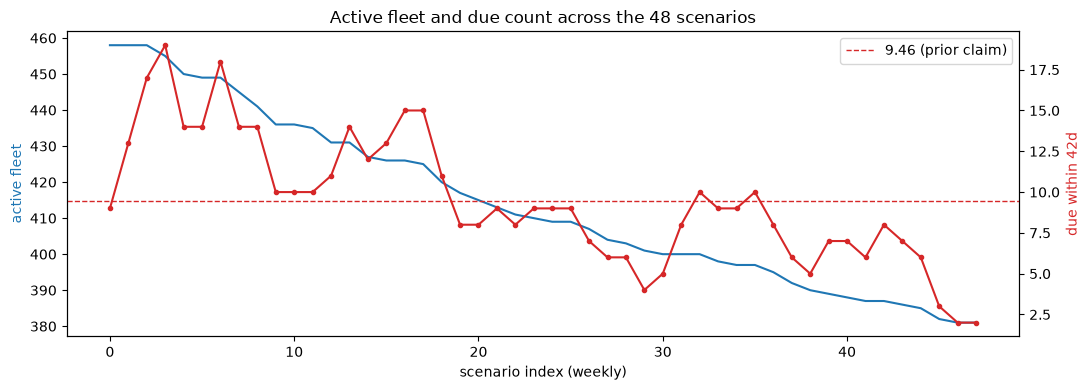

In [5]:
# Type fixes on the objects already in memory
devices["start_time"] = pd.to_datetime(devices["start_time"], format="ISO8601")
devices["end_time"]   = pd.to_datetime(devices["end_time"],   format="ISO8601")
eol_s = eol.set_index("device_id")["end_time"]          # already datetime64 from Step 1
if eol_s.dt.tz is None:
    eol_s = eol_s.dt.tz_localize("UTC")

# Q0: what IS devices.end_time?
print("distinct devices.end_time:", devices["end_time"].nunique(), "/", len(devices))
print(devices["end_time"].value_counts().head(5))

# Q1: active fleet and due count per scenario cutoff
eol_by_dev = eol_s.reindex(devices["device_id"]).values      # aligned to devices row order
start_by_dev = devices["start_time"].values

rows = []
for s in scenarios_raw:
    cutoff = pd.Timestamp(s["start_time"], tz="UTC")
    window_end = cutoff + pd.Timedelta(days=s["settings"]["planning_window_days"])

    deployed    = start_by_dev <= cutoff.to_datetime64()
    dead_before = (eol_by_dev <= cutoff.to_datetime64())      # NaT compares False
    active      = deployed & ~dead_before
    due         = active & (eol_by_dev > cutoff.to_datetime64()) & (eol_by_dev <= window_end.to_datetime64())

    rows.append({"scenario": s["name"], "cutoff": cutoff,
                 "n_active": int(active.sum()), "n_due": int(due.sum())})

sc = pd.DataFrame(rows)
display(sc.head(10))
print(sc[["n_active", "n_due"]].describe())
print(f"\nmean active = {sc.n_active.mean():.1f}   mean due = {sc.n_due.mean():.2f}   "
      f"due rate = {sc.n_due.sum()/sc.n_active.sum():.4f}")

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(sc.index, sc.n_active, color="tab:blue")
ax1.set_ylabel("active fleet", color="tab:blue"); ax1.set_xlabel("scenario index (weekly)")
ax2 = ax1.twinx()
ax2.plot(sc.index, sc.n_due, color="tab:red", marker=".")
ax2.axhline(9.46, color="tab:red", ls="--", lw=1, label="9.46 (prior claim)")
ax2.set_ylabel("due within 42d", color="tab:red"); ax2.legend(loc="upper right")
ax1.set_title("Active fleet and due count across the 48 scenarios")
plt.tight_layout(); plt.show()

C:\Users\welde\AppData\Local\Temp\ipykernel_36556\1042125559.py:11: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  sc["window_end"]     = sc["cutoff"] + pd.Timedelta(days=42)
C:\Users\welde\AppData\Local\Temp\ipykernel_36556\1042125559.py:15: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  sc["month"]           = (sc["cutoff"] + pd.Timedelta(days=21)).dt.month   # window centre
C:\Users\welde\AppData\Local\Temp\ipykernel_36556\1042125559.py:30: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  i

   scenario                    cutoff  n_active  n_due  obs_frac
38     s_38 2026-05-25 00:00:00+00:00       390      5  1.000000
39     s_39 2026-06-01 00:00:00+00:00       389      7  1.000000
40     s_40 2026-06-08 00:00:00+00:00       388      7  1.000000
41     s_41 2026-06-15 00:00:00+00:00       387      6  1.000000
42     s_42 2026-06-22 00:00:00+00:00       387      8  0.935516
43     s_43 2026-06-29 00:00:00+00:00       386      7  0.768849
44     s_44 2026-07-06 00:00:00+00:00       385      6  0.602183
45     s_45 2026-07-13 00:00:00+00:00       382      3  0.435516
46     s_46 2026-07-20 00:00:00+00:00       381      2  0.268849
47     s_47 2026-07-27 00:00:00+00:00       381      2  0.102183

fully observable scenarios (obs_frac==1): 42
s_0: mine=458  official-style=458
s_24: mine=409  official-style=409
s_47: mine=381  official-style=381

devices whose last reading is >30d before DATA_END: 123 / 461


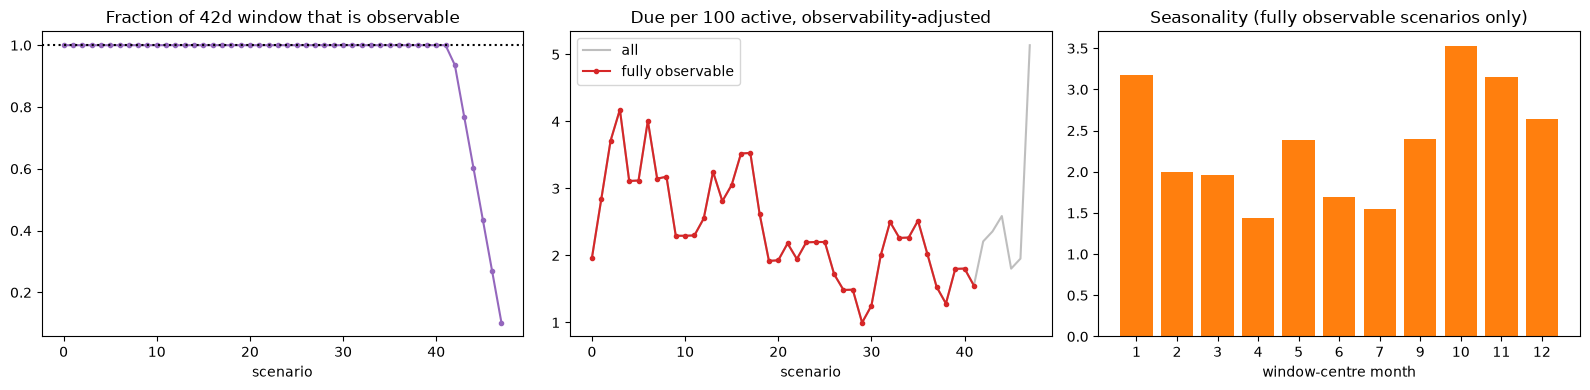

In [ ]:
DATA_END = pd.Timestamp("2026-07-31 07:00:00", tz="UTC")   # max end_time in parquet

# per-device last reading (reuse Step 1's polars summary)
last_read = (summary.select(["device_id", "last_reading"]).to_pandas()
             .set_index("device_id")["last_reading"])
last_read = pd.to_datetime(last_read).dt.tz_localize("UTC")

# A. observability: how much of each 42d window could contain a RECORDED eol
sc["window_end"]     = sc["cutoff"] + pd.Timedelta(days=42)
sc["observable_days"] = ((sc["window_end"].clip(upper=DATA_END) - sc["cutoff"])
                         .dt.total_seconds() / 86400).clip(lower=0)
sc["obs_frac"]        = sc["observable_days"] / 42
sc["month"]           = (sc["cutoff"] + pd.Timedelta(days=21)).dt.month   # window centre
sc["due_per_100_active_obs"] = sc.n_due / sc.n_active / sc.obs_frac * 100

print(sc[["scenario","cutoff","n_active","n_due","obs_frac"]].tail(10).to_string())
print("\nfully observable scenarios (obs_frac==1):", int((sc.obs_frac >= 1).sum()))

# B. official-iterator parity check on n_active (no start_time filter)
eol_by_dev = eol_s.reindex(devices["device_id"]).values
for i in [0, 24, 47]:
    c = sc.cutoff[i].to_datetime64()
    official = int((~(eol_by_dev <= c)).sum())          # only rule iterate_scenarios applies
    print(f"{sc.scenario[i]}: mine={sc.n_active[i]}  official-style={official}")

# C. does per-device observation end actually vary?
print("\ndevices whose last reading is >30d before DATA_END:",
      int((last_read < DATA_END - pd.Timedelta(days=30)).sum()), "/", len(last_read))

# D. plots
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(sc.index, sc.obs_frac, color="tab:purple", marker=".")
ax[0].set_title("Fraction of 42d window that is observable"); ax[0].set_xlabel("scenario"); ax[0].axhline(1, ls=":", c="k")

full = sc[sc.obs_frac >= 1]
ax[1].plot(sc.index, sc.due_per_100_active_obs, c="tab:gray", alpha=.5, label="all")
ax[1].plot(full.index, full.due_per_100_active_obs, c="tab:red", marker=".", label="fully observable")
ax[1].set_title("Due per 100 active, observability-adjusted"); ax[1].set_xlabel("scenario"); ax[1].legend()

bym = full.groupby("month")["due_per_100_active_obs"].mean()
ax[2].bar(bym.index.astype(str), bym.values, color="tab:orange")
ax[2].set_title("Seasonality (fully observable scenarios only)"); ax[2].set_xlabel("window-centre month")
plt.tight_layout(); plt.show()

daily table: (360847, 12)

A. EOL after last reading: 0 / 82

B. stale(>30d) x has_recorded_EOL
has_eol  False  True 
stale                
False      297     41
True        82     41


C:\Users\welde\AppData\Local\Temp\ipykernel_36556\1124058350.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  last_obs = d.groupby("device_id")["date"].max()
C:\Users\welde\AppData\Local\Temp\ipykernel_36556\1124058350.py:50: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  stale = last_obs < DATA_END_D - pd.Timedelta(days=30)
C:\Users\welde\AppData\Local\Temp\ipykernel_36556\1124058350.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lo 


C. staleness at cutoff
      n_active_with_data  gap_median  frac_gap_gt7  frac_gap_gt30  due_gap_max
mean             414.375         0.0      0.139058       0.114603    14.541667
min              381.000         0.0      0.026201       0.024017     0.000000
max              458.000         0.0      0.256281       0.201511   132.000000

largest gap among DUE batteries, worst scenario: 132


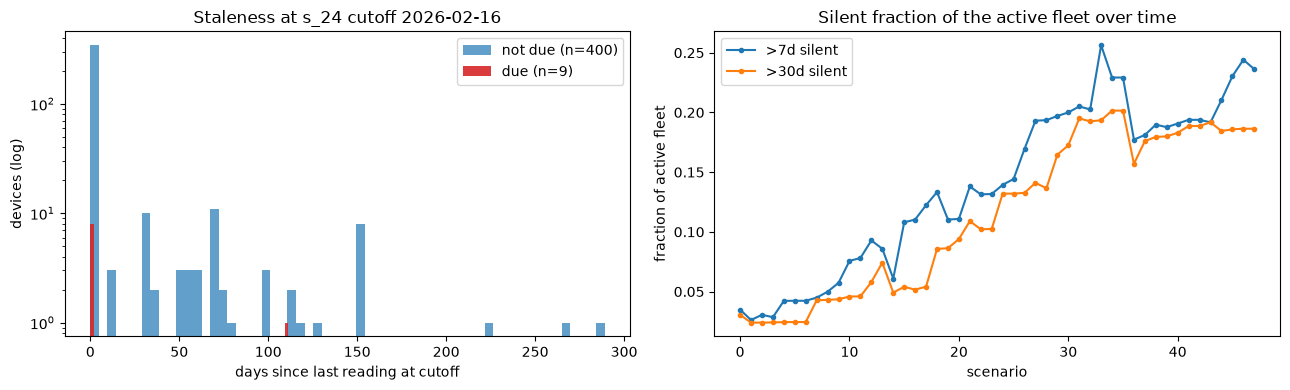

In [7]:
from pathlib import Path

CACHE = Path("data/processed"); CACHE.mkdir(parents=True, exist_ok=True)
DAILY_PATH = CACHE / "daily_raw.parquet"

if DAILY_PATH.exists():
    daily = pl.read_parquet(DAILY_PATH)
else:
    daily = (
        pl.scan_parquet(DATA_DIR / "battery_metrics.parquet")
          .with_columns(pl.col("end_time").dt.date().alias("date"))
          .group_by(["device_id", "date"])
          .agg([
              pl.len().alias("n_obs"),
              pl.col("voltage").mean().alias("v_mean"),
              pl.col("voltage").median().alias("v_med"),
              pl.col("voltage").min().alias("v_min"),
              pl.col("voltage").max().alias("v_max"),
              pl.col("temperature").mean().alias("t_mean"),
              pl.col("temperature").min().alias("t_min"),
              pl.col("temperature").max().alias("t_max"),
              # median voltage restricted to the 10-30C band smooth_series uses
              pl.col("voltage").filter(
                  (pl.col("temperature") > 10) & (pl.col("temperature") < 30)
              ).median().alias("v_med_stable"),
              pl.col("temperature").filter(
                  (pl.col("temperature") > 10) & (pl.col("temperature") < 30)
              ).len().alias("n_stable"),
          ])
          .sort(["device_id", "date"])
          .collect()
    )
    daily.write_parquet(DAILY_PATH)

print("daily table:", daily.shape)
d = daily.to_pandas()
d["date"] = pd.to_datetime(d["date"])

last_obs = d.groupby("device_id")["date"].max()
eol_naive = eol_s.dt.tz_localize(None)

# A. is EOL always at or before the device's last reading?
both = pd.DataFrame({"eol": eol_naive, "last_obs": last_obs}).dropna(subset=["eol"])
viol = both[both.eol > both.last_obs]
print(f"\nA. EOL after last reading: {len(viol)} / {len(both)}")
if len(viol): display(viol.head())

# B. who are the silent devices?
DATA_END_D = d["date"].max()
stale = last_obs < DATA_END_D - pd.Timedelta(days=30)
has_eol = eol_naive.reindex(last_obs.index).notna()
print("\nB. stale(>30d) x has_recorded_EOL")
print(pd.crosstab(stale.rename("stale"), has_eol.rename("has_eol")))

# C. staleness at each cutoff, and whether due batteries are ever stale
rows = []
for name, cutoff in zip(sc.scenario, sc.cutoff):
    c = cutoff.tz_localize(None)
    lo = d[d.date <= c].groupby("device_id")["date"].max()
    alive = ~(eol_naive <= c).reindex(lo.index).fillna(False)
    lo = lo[alive]
    gap = (c - lo).dt.days
    due_ids = eol_naive[(eol_naive > c) & (eol_naive <= c + pd.Timedelta(days=42))].index
    rows.append({
        "scenario": name,
        "n_active_with_data": len(lo),
        "gap_median": gap.median(),
        "frac_gap_gt7":  (gap > 7).mean(),
        "frac_gap_gt30": (gap > 30).mean(),
        "due_gap_max": gap.reindex(due_ids).max(),
    })
stale_sc = pd.DataFrame(rows)
print("\nC. staleness at cutoff")
print(stale_sc.describe().loc[["mean","min","max"]].to_string())
print("\nlargest gap among DUE batteries, worst scenario:", stale_sc.due_gap_max.max())

# D. distribution at a mid scenario, due vs not-due
c = sc.cutoff[24].tz_localize(None)
lo = d[d.date <= c].groupby("device_id")["date"].max()
alive = ~(eol_naive <= c).reindex(lo.index).fillna(False)
lo = lo[alive]; gap = (c - lo).dt.days
due_ids = set(eol_naive[(eol_naive > c) & (eol_naive <= c + pd.Timedelta(days=42))].index)
is_due = gap.index.isin(due_ids)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(gap[~is_due], bins=60, log=True, alpha=.7, label=f"not due (n={(~is_due).sum()})")
ax[0].hist(gap[is_due],  bins=60, log=True, alpha=.9, label=f"due (n={is_due.sum()})", color="tab:red")
ax[0].set_xlabel("days since last reading at cutoff"); ax[0].set_ylabel("devices (log)")
ax[0].set_title(f"Staleness at {sc.scenario[24]} cutoff {c.date()}"); ax[0].legend()

ax[1].plot(stale_sc.index, stale_sc.frac_gap_gt7,  marker=".", label=">7d silent")
ax[1].plot(stale_sc.index, stale_sc.frac_gap_gt30, marker=".", label=">30d silent")
ax[1].set_xlabel("scenario"); ax[1].set_ylabel("fraction of active fleet")
ax[1].set_title("Silent fraction of the active fleet over time"); ax[1].legend()
plt.tight_layout(); plt.show()

## Phase 2

smoothed: (386469, 5)
d_57e99ff00802: n=979 official=979 mine=979 maxabsdiff=1.192e-07
d_f44ef99c6628: n=961 official=961 mine=962 maxabsdiff=1.192e-07


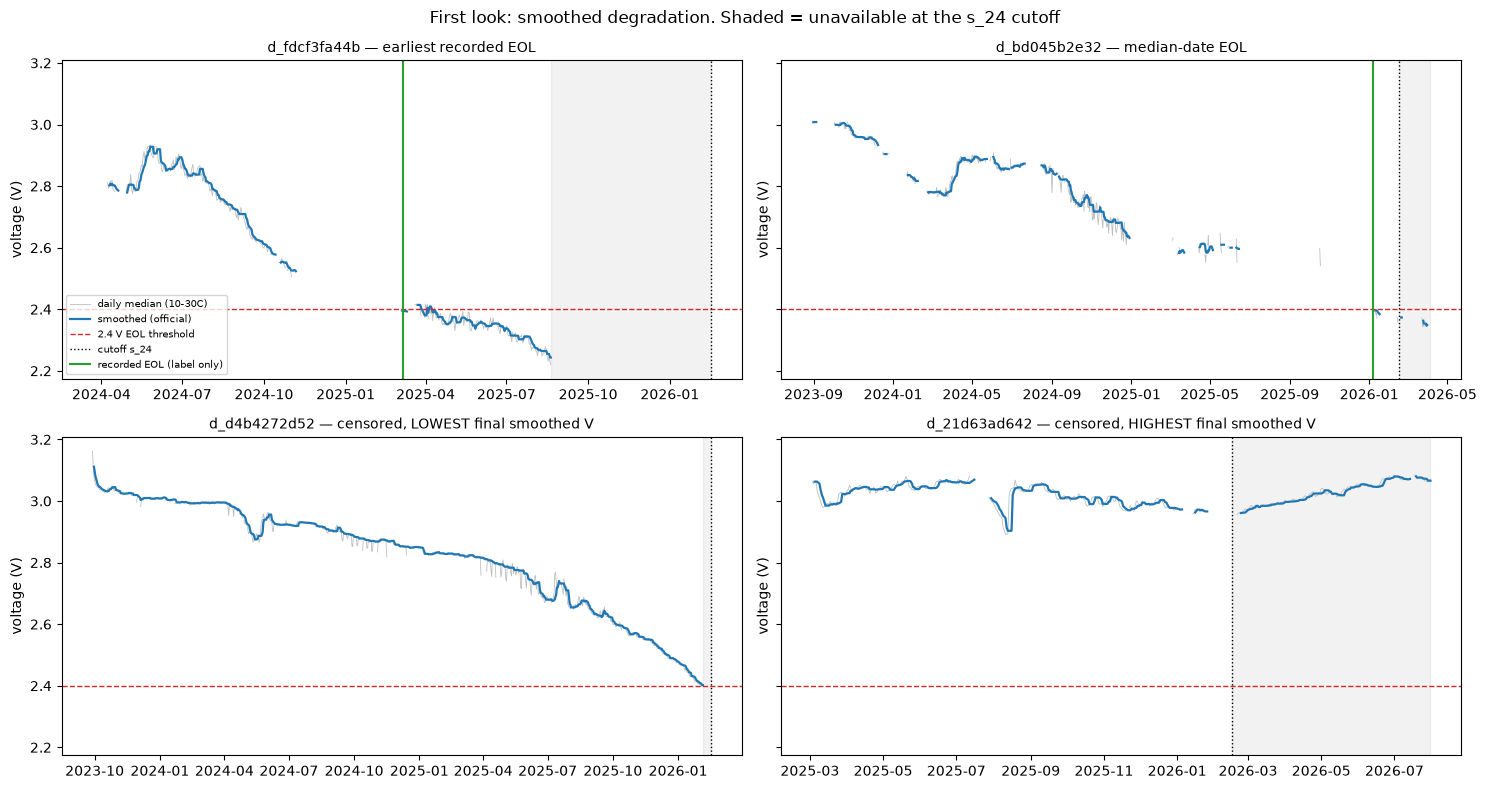

In [ ]:
import warnings, numpy as np
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

CACHE = Path("data/processed"); SMOOTH_PATH = CACHE / "smoothed.parquet"

def build_smoothed(dd):
    """Reproduce batteryswap_public.utils.smooth_series from the daily table.
    Official: daily median of readings in 10<T<30 requiring >=5 such readings,
    laid on a REGULAR daily grid (NaN where the count rule fails),
    then rolling(7, min_periods=int(0.5*7)=3).median()."""
    out = []
    for dev, g in dd.groupby("device_id", observed=True):
        g = g.set_index("date").sort_index()
        grid = pd.date_range(g.index.min(), g.index.max(), freq="D")
        v = g["v_med_stable"].where(g["n_stable"] >= 5).reindex(grid)
        t = g["t_mean"].reindex(grid)
        out.append(pd.DataFrame({
            "device_id": dev, "date": grid,
            "v_smooth": v.rolling(7, min_periods=3).median(),
            "v_daily_stable": v, "t_daily": t,
        }))
    return pd.concat(out, ignore_index=True)

if SMOOTH_PATH.exists():
    sm = pd.read_parquet(SMOOTH_PATH)
else:
    sm = build_smoothed(d); sm.to_parquet(SMOOTH_PATH, index=False)
print("smoothed:", sm.shape)

# --- validate against the OFFICIAL function on 2 devices ---
from batteryswap_public.utils import smooth_series
check_devs = [eol_naive.dropna().index[0], eol_naive[eol_naive.isna()].index[0]]
raw = (pl.scan_parquet(DATA_DIR / "battery_metrics.parquet")
         .filter(pl.col("device_id").is_in(check_devs))
         .select(["device_id","end_time","voltage","temperature"]).collect().to_pandas())
official = smooth_series(raw).reset_index()
for dev in check_devs:
    o = official[official.device_id == dev].set_index("end_time")["voltage"].dropna()
    m = sm[sm.device_id == dev].set_index("date")["v_smooth"].dropna()
    j = pd.concat([o.rename("official"), m.rename("mine")], axis=1).dropna()
    print(f"{dev}: n={len(j)} official={len(o)} mine={len(m)} maxabsdiff={np.abs(j.official-j.mine).max():.3e}")

# --- first look: 4 systematically chosen batteries ---
eol_dev = eol_naive.dropna().sort_values()
final_v = sm.dropna(subset=["v_smooth"]).groupby("device_id").tail(1).set_index("device_id")["v_smooth"]
cens = eol_naive[eol_naive.isna()].index
picks = [
    (eol_dev.index[0],            "earliest recorded EOL"),
    (eol_dev.index[len(eol_dev)//2], "median-date EOL"),
    (final_v.reindex(cens).idxmin(),  "censored, LOWEST final smoothed V"),
    (final_v.reindex(cens).idxmax(),  "censored, HIGHEST final smoothed V"),
]
CUT = sc.cutoff[24].tz_localize(None)

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=True)
for ax, (dev, label) in zip(axes.ravel(), picks):
    g = sm[sm.device_id == dev]
    ax.plot(g.date, g.v_daily_stable, lw=.6, color="0.75", label="daily median (10-30C)")
    ax.plot(g.date, g.v_smooth, lw=1.6, color="tab:blue", label="smoothed (official)")
    ax.axhline(2.4, color="tab:red", ls="--", lw=1, label="2.4 V EOL threshold")
    ax.axvline(CUT, color="k", ls=":", lw=1, label=f"cutoff {sc.scenario[24]}")
    ax.axvspan(CUT, g.date.max(), color="k", alpha=.05)   # not knowable at cutoff
    e = eol_naive.get(dev)
    if pd.notna(e):
        ax.axvline(e, color="tab:green", lw=1.5, label="recorded EOL (label only)")
    ax.set_title(f"{dev[:12]} — {label}", fontsize=10)
    ax.set_ylabel("voltage (V)")
axes[0,0].legend(fontsize=7, loc="lower left")
fig.suptitle("First look: smoothed degradation. Shaded = unavailable at the s_24 cutoff")
plt.tight_layout(); plt.show()

smoothed: (385153, 6)

device             off  mine    maxdiff
d_ccd6076a4a3c     807   807   0.00e+00
d_c76f521a00b2     786   786   0.00e+00
d_97f334f0b4f5     347   347   0.00e+00
d_e87ebf12f990     807   807   0.00e+00
d_ab77e1f67872     559   559   0.00e+00
d_3049b6345348     427   427   0.00e+00
d_57e99ff00802     979   979   0.00e+00
d_cbf684280da2     553   553   0.00e+00

--- final smoothed voltage, censored vs recorded-EOL ---
         count      mean       25%       50%       75%       min
has_eol                                                         
False    379.0  2.726340  2.570207  2.696571  2.872552  2.402079
True      82.0  2.327966  2.266012  2.307985  2.377513  2.088148
censored devices ending at or below 2.40 V:   0  ( 0.0% of censored)
censored devices ending at or below 2.45 V:  17  ( 4.5% of censored)
censored devices ending at or below 2.50 V:  41  (10.8% of censored)
censored devices ending at or below 2.55 V:  73  (19.3% of censored)
censored devices ending

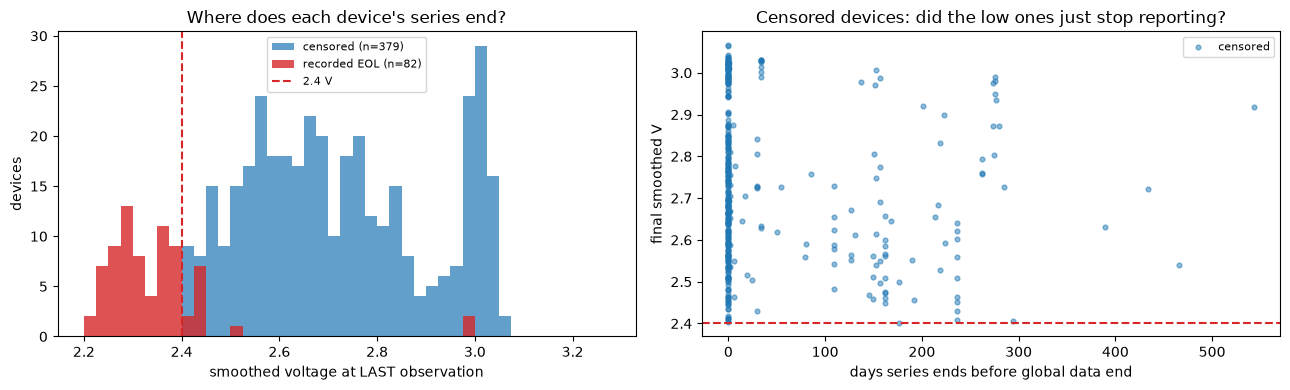

In [12]:
import warnings, numpy as np
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

DAILY_PATH, SMOOTH_PATH = CACHE/"daily_raw.parquet", CACHE/"smoothed.parquet"
for p in (DAILY_PATH, SMOOTH_PATH):          # force rebuild: float64 + grid fix
    if p.exists(): p.unlink()

daily = (
    pl.scan_parquet(DATA_DIR / "battery_metrics.parquet")
      .with_columns([pl.col("voltage").cast(pl.Float64),
                     pl.col("temperature").cast(pl.Float64),
                     pl.col("end_time").dt.date().alias("date")])
      .group_by(["device_id", "date"])
      .agg([
          pl.len().alias("n_obs"),
          pl.col("voltage").mean().alias("v_mean"),
          pl.col("voltage").min().alias("v_min"),
          pl.col("voltage").max().alias("v_max"),
          pl.col("temperature").mean().alias("t_mean"),
          pl.col("temperature").min().alias("t_min"),
          pl.col("temperature").max().alias("t_max"),
          pl.col("voltage").filter((pl.col("temperature")>10)&(pl.col("temperature")<30))
            .median().alias("v_med_stable"),
          pl.col("temperature").filter((pl.col("temperature")>10)&(pl.col("temperature")<30))
            .median().alias("t_med_stable"),
          pl.col("voltage").filter((pl.col("temperature")>10)&(pl.col("temperature")<30))
            .len().alias("n_stable"),
      ]).sort(["device_id","date"]).collect()
)
daily.write_parquet(DAILY_PATH)
d = daily.to_pandas(); d["date"] = pd.to_datetime(d["date"])

def build_smoothed(dd):
    """Exact reproduction of smooth_series: the daily grid spans first->last day
    with >=1 reading in 10<T<30 (the temperature-filtered subset defines the grid),
    values NaN unless >=5 such readings, then rolling(7, min_periods=3).median()."""
    out = []
    for dev, g in dd.groupby("device_id", observed=True):
        g = g.set_index("date").sort_index()
        has_stable = g.index[g["n_stable"] >= 1]
        if len(has_stable) == 0: continue
        grid = pd.date_range(has_stable.min(), has_stable.max(), freq="D")   # <-- the fix
        v = g["v_med_stable"].where(g["n_stable"] >= 5).reindex(grid)
        out.append(pd.DataFrame({
            "device_id": dev, "date": grid,
            "v_smooth": v.rolling(7, min_periods=3).median(),
            "v_daily_stable": v,
            "t_daily": g["t_med_stable"].reindex(grid),
            "n_obs": g["n_obs"].reindex(grid).fillna(0).astype(int),
        }))
    return pd.concat(out, ignore_index=True)

sm = build_smoothed(d); sm.to_parquet(SMOOTH_PATH, index=False)
print("smoothed:", sm.shape)

# --- verify on 8 devices, row counts AND values ---
from batteryswap_public.utils import smooth_series
rng = np.random.default_rng(0)
check = list(rng.choice(devices["device_id"].values, 6, replace=False))
check += [eol_naive.dropna().index[0], eol_naive.dropna().index[-1]]
raw = (pl.scan_parquet(DATA_DIR/"battery_metrics.parquet")
         .filter(pl.col("device_id").is_in(check))
         .select(["device_id","end_time","voltage","temperature"]).collect().to_pandas())
official = smooth_series(raw).reset_index()
print(f"\n{'device':16s} {'off':>5s} {'mine':>5s} {'maxdiff':>10s}")
for dev in check:
    o = official[official.device_id==dev].set_index("end_time")["voltage"].dropna()
    m = sm[sm.device_id==dev].set_index("date")["v_smooth"].dropna()
    j = pd.concat([o.rename("o"), m.rename("m")], axis=1).dropna()
    print(f"{dev[:16]:16s} {len(o):5d} {len(m):5d} {np.abs(j.o-j.m).max():10.2e}")

# --- POPULATION TEST of the missing-label hypothesis ---
last = sm.dropna(subset=["v_smooth"]).sort_values("date").groupby("device_id").tail(1)
last = last.set_index("device_id")
last["has_eol"] = eol_naive.reindex(last.index).notna()
last["days_before_dataend"] = (sm.date.max() - last["date"]).dt.days

print("\n--- final smoothed voltage, censored vs recorded-EOL ---")
print(last.groupby("has_eol")["v_smooth"].describe()[["count","mean","25%","50%","75%","min"]])

cens = last[~last.has_eol]
for thr in [2.40, 2.45, 2.50, 2.55, 2.60]:
    n = int((cens.v_smooth <= thr).sum())
    print(f"censored devices ending at or below {thr:.2f} V: {n:3d}  ({n/len(cens):5.1%} of censored)")

near = cens[cens.v_smooth <= 2.50]
print(f"\nof those {len(near)} near-threshold censored devices, "
      f"median days their series ends before the global data end: "
      f"{near.days_before_dataend.median():.0f}")
print("  ended >30d early:", int((near.days_before_dataend>30).sum()), "/", len(near))

fig, ax = plt.subplots(1, 2, figsize=(13,4))
bins = np.arange(2.2, 3.3, 0.025)
ax[0].hist(last.loc[~last.has_eol,"v_smooth"], bins=bins, alpha=.7, label=f"censored (n={(~last.has_eol).sum()})")
ax[0].hist(last.loc[ last.has_eol,"v_smooth"], bins=bins, alpha=.8, color="tab:red", label=f"recorded EOL (n={last.has_eol.sum()})")
ax[0].axvline(2.4, color="tab:red", ls="--", label="2.4 V")
ax[0].set_xlabel("smoothed voltage at LAST observation"); ax[0].set_ylabel("devices")
ax[0].set_title("Where does each device's series end?"); ax[0].legend(fontsize=8)

ax[1].scatter(cens.days_before_dataend, cens.v_smooth, s=12, alpha=.5, label="censored")
ax[1].axhline(2.4, color="tab:red", ls="--")
ax[1].set_xlabel("days series ends before global data end"); ax[1].set_ylabel("final smoothed V")
ax[1].set_title("Censored devices: did the low ones just stop reporting?"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

feature table: (19890, 24) | due rate: 0.0228 | rows with no usable series: 0

--- feature distributions, due vs not-due (42 full scenarios) ---
due               not_due         due
margin           0.402533    0.070658
slope_30        -0.000582   -0.001917
slope_90        -0.000609   -0.001588
eta_30        1255.934987   48.579463
age_days       676.000000  783.000000
gap_days         0.000000    0.000000
v_stale_days     0.000000    0.000000

--- scenario-level Precision@12 / Recall@12 (K=12, 42 scenarios) ---
rule                            P@12    R@12
random baseline                0.029       -
lowest voltage (margin)        0.369   0.435
steepest 30d slope             0.085   0.107
steepest 90d slope             0.095   0.093
margin / -slope_30             0.351   0.404
margin / -slope_60             0.361   0.415
margin / -slope_90             0.353   0.404


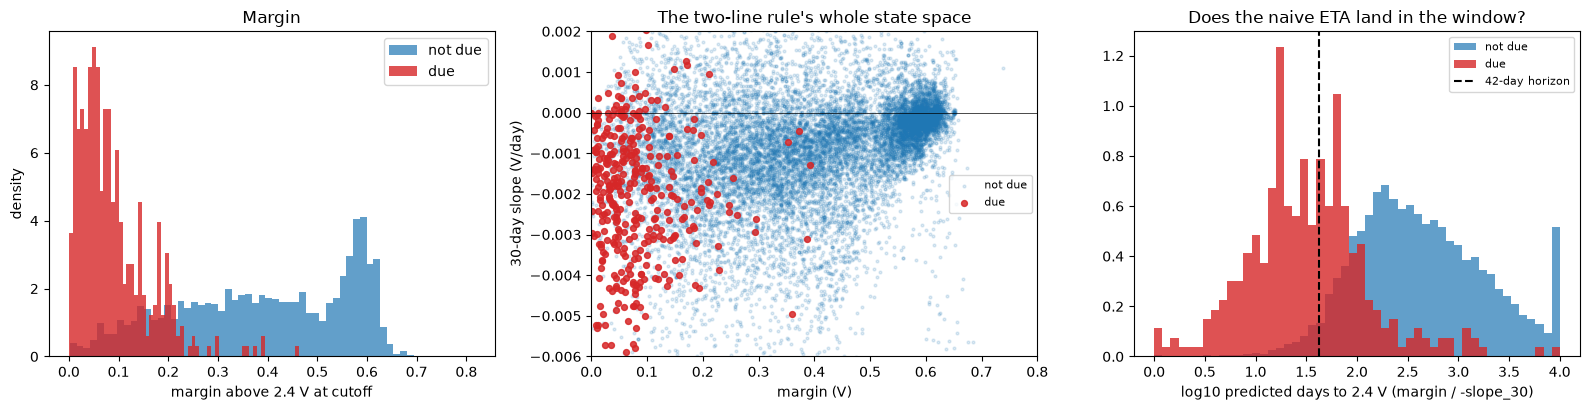

In [13]:
import numpy as np, warnings
warnings.filterwarnings("ignore")
FEAT_PATH = CACHE / "cutoff_features.parquet"
V_EOL, WINDOWS = 2.4, [7, 14, 30, 60, 90]

def ols_slope(x, y):
    if len(x) < 3: return np.nan
    xm, ym = x.mean(), y.mean(); den = ((x - xm) ** 2).sum()
    return np.nan if den == 0 else ((x - xm) * (y - ym)).sum() / den

if FEAT_PATH.exists():
    feat = pd.read_parquet(FEAT_PATH)
else:
    # per-device arrays, built ONCE; all cutoff logic is searchsorted on these
    S = {}
    for dev, g in sm.dropna(subset=["v_smooth"]).groupby("device_id", observed=True):
        g = g.sort_values("date")
        S[dev] = (g["date"].values.astype("datetime64[D]").astype(int), g["v_smooth"].values)
    RAW = {dev: g.loc[g.n_obs > 0, "date"].max()
           for dev, g in d.groupby("device_id", observed=True)}
    meta = devices.set_index("device_id")
    start_day = meta["start_time"].dt.tz_localize(None).dt.normalize()

    rows = []
    for name, cutoff in zip(sc.scenario, sc.cutoff):
        c = cutoff.tz_localize(None); ci = np.datetime64(c, "D").astype(int)
        wend = c + pd.Timedelta(days=42)
        for dev in meta.index:
            e = eol_naive.get(dev)
            if pd.notna(e) and e <= c:            # already dead -> not in the fleet
                continue
            r = {"scenario": name, "cutoff": c, "device_id": dev,
                 "building": meta.at[dev, "building_id"], "room": meta.at[dev, "room_id"],
                 "due": bool(pd.notna(e) and c < e <= wend),
                 "age_days": (c - start_day[dev]).days,
                 "gap_days": (c - RAW[dev]).days if RAW[dev] <= c else 0}
            if dev in S:
                t, v = S[dev]
                k = np.searchsorted(t, ci, side="right")     # STRICT truncation at cutoff
                if k >= 3:
                    t_, v_ = t[:k], v[:k]
                    r["v_last"] = v_[-1]
                    r["margin"] = v_[-1] - V_EOL
                    r["v_stale_days"] = ci - t_[-1]
                    r["n_days_obs"] = k
                    r["v_runmin"] = v_.min()
                    r["days_since_runmin"] = ci - t_[v_.argmin()]
                    for W in WINDOWS:
                        m = t_ >= ci - W
                        r[f"slope_{W}"] = ols_slope(t_[m].astype(float), v_[m]) if m.sum() >= 3 else np.nan
            rows.append(r)
    feat = pd.DataFrame(rows)
    for W in WINDOWS:                                   # days-to-threshold at each scale
        feat[f"eta_{W}"] = np.where(feat[f"slope_{W}"] < -1e-6,
                                    feat["margin"] / -feat[f"slope_{W}"], np.inf)
    feat.to_parquet(FEAT_PATH, index=False)

print("feature table:", feat.shape, "| due rate:", f"{feat.due.mean():.4f}",
      "| rows with no usable series:", int(feat.margin.isna().sum()))

FULL = set(sc.scenario[sc.obs_frac >= 1])               # 42 untruncated scenarios only
f = feat[feat.scenario.isin(FULL)].copy()

print("\n--- feature distributions, due vs not-due (42 full scenarios) ---")
cols = ["margin", "slope_30", "slope_90", "eta_30", "age_days", "gap_days", "v_stale_days"]
print(f.groupby("due")[cols].median().T.rename(columns={False: "not_due", True: "due"}))

def prec_at_k(frame, score, K=12, ascending=True):
    p, r = [], []
    for _, g in frame.groupby("scenario"):
        g = g.dropna(subset=[score]) if score in g else g
        g = g.sort_values(score, ascending=ascending)
        top = g.head(K)
        p.append(top.due.mean())
        r.append(top.due.sum() / max(g.due.sum(), 1))
    return np.mean(p), np.mean(r)

print(f"\n--- scenario-level Precision@12 / Recall@12 (K=12, {len(FULL)} scenarios) ---")
print(f"{'rule':28s} {'P@12':>7s} {'R@12':>7s}")
print(f"{'random baseline':28s} {12/f.groupby('scenario').size().mean():7.3f} {'-':>7s}")
for nm, col, asc in [("lowest voltage (margin)", "margin", True),
                     ("steepest 30d slope", "slope_30", True),
                     ("steepest 90d slope", "slope_90", True),
                     ("margin / -slope_30", "eta_30", True),
                     ("margin / -slope_60", "eta_60", True),
                     ("margin / -slope_90", "eta_90", True)]:
    pk, rk = prec_at_k(f, col, ascending=asc)
    print(f"{nm:28s} {pk:7.3f} {rk:7.3f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(f.loc[~f.due, "margin"].dropna(), bins=60, alpha=.7, density=True, label="not due")
ax[0].hist(f.loc[ f.due, "margin"].dropna(), bins=60, alpha=.8, density=True, color="tab:red", label="due")
ax[0].set_xlabel("margin above 2.4 V at cutoff"); ax[0].set_ylabel("density"); ax[0].legend(); ax[0].set_title("Margin")

nd, dd = f[~f.due], f[f.due]
ax[1].scatter(nd.margin, nd.slope_30, s=4, alpha=.15, label="not due")
ax[1].scatter(dd.margin, dd.slope_30, s=18, alpha=.85, color="tab:red", label="due")
ax[1].set_xlim(0, 0.8); ax[1].set_ylim(-0.006, 0.002)
ax[1].axhline(0, color="k", lw=.5)
ax[1].set_xlabel("margin (V)"); ax[1].set_ylabel("30-day slope (V/day)")
ax[1].set_title("The two-line rule's whole state space"); ax[1].legend(fontsize=8)

e = f.replace([np.inf], np.nan)
ax[2].hist(np.log10(e.loc[~e.due, "eta_30"].dropna().clip(1, 1e4)), bins=50, alpha=.7, density=True, label="not due")
ax[2].hist(np.log10(e.loc[ e.due, "eta_30"].dropna().clip(1, 1e4)), bins=50, alpha=.8, density=True, color="tab:red", label="due")
ax[2].axvline(np.log10(42), color="k", ls="--", label="42-day horizon")
ax[2].set_xlabel("log10 predicted days to 2.4 V (margin / -slope_30)"); ax[2].legend(fontsize=8)
ax[2].set_title("Does the naive ETA land in the window?")
plt.tight_layout(); plt.show()

--- candidate generation: how good is a pure margin filter? ---
 margin<  cand/scen  due in  due out  recall  purity
    0.05       10.0     150      276   0.352   0.356
    0.10       29.1     292      134   0.685   0.239
    0.15       53.4     356       70   0.836   0.159
    0.20       80.2     396       30   0.930   0.118
    0.30      142.0     420        6   0.986   0.070
    0.40      211.3     425        1   0.998   0.048

Danger zone (margin<0.2): 2383 rows, 336 due, base rate 0.141

--- separation INSIDE the danger zone ---
feature                  AUC  perScen    med(due)    med(not)
margin                 0.803    0.845     0.06168      0.1349
v_runmin               0.767    0.822       2.448       2.515
slope_30               0.654    0.657   -0.001956   -0.001124
slope_60               0.653    0.627   -0.001792   -0.001203
slope_14               0.630    0.645    -0.00209   -0.001117
slope_90               0.613    0.627   -0.001714   -0.001255
curv_30_90             0.

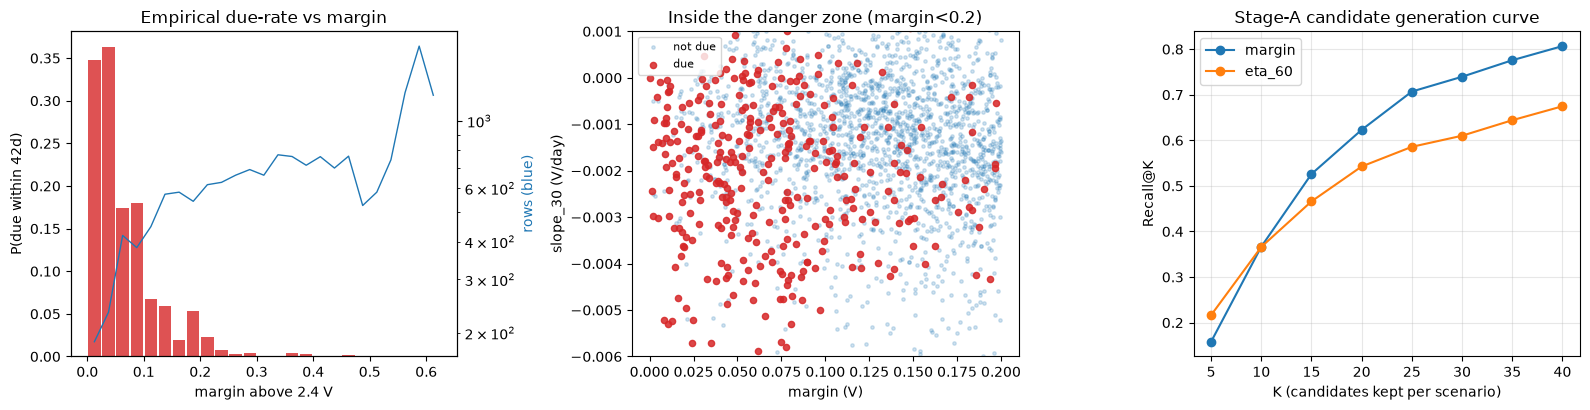

In [14]:
from sklearn.metrics import roc_auc_score

f = f.copy()
f["curv_30_90"]  = f.slope_30 - f.slope_90        # <0 = decline accelerating
f["curv_7_30"]   = f.slope_7  - f.slope_30
f["above_runmin"] = f.v_last - f.v_runmin
f["v_drop_90"]   = f.slope_90 * 90                # modelled 90d fall

print("--- candidate generation: how good is a pure margin filter? ---")
print(f"{'margin<':>8s} {'cand/scen':>10s} {'due in':>7s} {'due out':>8s} {'recall':>7s} {'purity':>7s}")
for thr in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]:
    z = f[f.margin < thr]
    per = z.groupby("scenario").size().mean()
    din, dout = z.due.sum(), f.due.sum() - z.due.sum()
    print(f"{thr:8.2f} {per:10.1f} {din:7d} {dout:8d} {din/f.due.sum():7.3f} {z.due.mean():7.3f}")

ZONE = 0.20
z = f[f.margin < ZONE].dropna(subset=["slope_30","slope_90","slope_7"])
print(f"\nDanger zone (margin<{ZONE}): {len(z)} rows, {z.due.sum()} due, base rate {z.due.mean():.3f}")

feats = ["margin","slope_7","slope_14","slope_30","slope_60","slope_90",
         "curv_30_90","curv_7_30","above_runmin","days_since_runmin",
         "age_days","n_days_obs","gap_days","v_stale_days","v_runmin"]
print(f"\n--- separation INSIDE the danger zone ---")
print(f"{'feature':20s} {'AUC':>7s} {'perScen':>8s} {'med(due)':>11s} {'med(not)':>11s}")
res = []
for c in feats:
    s = z[c].astype(float)
    if s.nunique() < 3: continue
    auc = roc_auc_score(z.due, -s)                       # AUC for "lower = riskier"
    auc = max(auc, 1 - auc)                              # report separation strength
    per = [roc_auc_score(g.due, -g[c].astype(float)) for _, g in z.groupby("scenario")
           if g.due.nunique() == 2 and g[c].nunique() > 2]
    per = np.mean([max(a, 1 - a) for a in per]) if per else np.nan
    res.append((c, auc, per, z.loc[z.due, c].median(), z.loc[~z.due, c].median()))
for c, a, p, md, mn in sorted(res, key=lambda r: -r[1]):
    print(f"{c:20s} {a:7.3f} {p:8.3f} {md:11.4g} {mn:11.4g}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
bins = np.arange(0, 0.65, 0.025)
f["mb"] = pd.cut(f.margin, bins)
rate = f.groupby("mb", observed=True)["due"].agg(["mean", "size"])
ax[0].bar([i.mid for i in rate.index], rate["mean"], width=.022, color="tab:red", alpha=.8)
ax[0].set_xlabel("margin above 2.4 V"); ax[0].set_ylabel("P(due within 42d)")
ax[0].set_title("Empirical due-rate vs margin")
a0 = ax[0].twinx(); a0.plot([i.mid for i in rate.index], rate["size"], color="tab:blue", lw=1)
a0.set_ylabel("rows (blue)", color="tab:blue"); a0.set_yscale("log")

ax[1].scatter(z.loc[~z.due,"margin"], z.loc[~z.due,"slope_30"], s=6, alpha=.2, label="not due")
ax[1].scatter(z.loc[ z.due,"margin"], z.loc[ z.due,"slope_30"], s=20, alpha=.85, color="tab:red", label="due")
ax[1].set_xlabel("margin (V)"); ax[1].set_ylabel("slope_30 (V/day)"); ax[1].set_ylim(-0.006, 0.001)
ax[1].set_title(f"Inside the danger zone (margin<{ZONE})"); ax[1].legend(fontsize=8)

ks = range(5, 41, 5)
for nm, col in [("margin", "margin"), ("eta_60", "eta_60")]:
    ys = []
    for K in ks:
        r = [g.sort_values(col).head(K).due.sum() / max(g.due.sum(), 1)
             for _, g in f.groupby("scenario")]
        ys.append(np.mean(r))
    ax[2].plot(list(ks), ys, marker="o", label=nm)
ax[2].set_xlabel("K (candidates kept per scenario)"); ax[2].set_ylabel("Recall@K")
ax[2].set_title("Stage-A candidate generation curve"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()